# Calculate and plot SNR and other parameters for SPIRou fits files

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.io import fits
import os
import h5py

# import ptp scatter
from sys import path
path.append('/home/mathisb/Github')
from HRS_analysis.ptp_scatter import ptp_scatter

# Make the plots more readable
plt.rcParams.update({'font.size': 14})

In [2]:
nightlist = ["2019-06-14",
               "2019-09-25",
               "2020-05-31",
               "2020-08-04",
               "2020-09-08",
               "2020-09-20",
               "2020-09-26",
               "2020-09-29",
               "2021-10-21",
               "2021-10-24",
               "2021-10-27"
               ]

## Functions to calculate SNR and other parameters

In [3]:
def calc_snr(file, order, plot_ord=False):
    '''
    Calculates the snr of a single order of a single exposure.
    Also returns the signal and noise separately.
    '''

    # Start by plotting 1 order
    with fits.open(file) as orig:
        raw_data = orig[1].data

    raw_ord = raw_data[order]
    
    if plot_ord:
        plt.plot(raw_ord)
        plt.ylim(np.nanmin(raw_ord) - 100, np.nanmax(raw_ord) + 100)
        plt.show()
 
    # Calculate the signal
    signal = np.nanmedian(raw_ord)  # signal is median flux of order

    # Calculate the ptp scatter
    noise = np.nanmedian(ptp_scatter(np.arange(np.shape(raw_ord)[0]), raw_ord))

    # Calculate SNR of this order
    snr = signal / noise
    
    return snr, signal, noise

In [4]:
def get_snr_night(night, e_or_t):
    '''
    Get SNR for each exposure and order of the specified night.
    Also calculates it for the sky observations.
    e_or_t: choose either "e.fits" or "t.fits" files
    
    Output
    ------
    snr_time_ord:       shape (nExp,nOrd)    --    all snr values computed by ptp scatter, per exposure (nExp) and order (nOrd)
    signal_time_ord:    shape (nExp,nOrd)    --    all signal values computed by ptp scatter, per exposure (nExp) and order (nOrd)
    noise_time_ord:     shape (nExp,nOrd)    --    all noise values computed by ptp scatter, per exposure (nExp) and order (nOrd)
    sky_info:           shape (3,nOrd)       --    snr, signal and noise values (rows 0, 1 and 2) per order (nOrd) for the sky observation
    
    '''

    # For TRAPPIST-1 SPIRou data
    obs_dir='/home/mathisb/Github/HRS_data/SPIRou_with_persi/TRAPPIST-1/'
    orders = np.arange(49)
    
    
    # Get sky filename and calculate snr
    sky_info = np.zeros((3, len(orders)))  # three columns for snr, signal and noise
    sky_fits = os.listdir(obs_dir + night + "/sky")
                        
    if sky_fits:  # if there is a fits file in the sky folder (sometimes there is no sky for a night)
        sky_file = obs_dir + night + "/sky/" + sky_fits[0]
        
        for n_ord in orders:
            sky_info[0, n_ord], sky_info[1, n_ord], sky_info[2, n_ord] = calc_snr(sky_file, n_ord)

                
    # Get list of filenames for transit observations
    filenames = []

    for i in sorted(os.listdir(obs_dir + night)):
        if i[-len(e_or_t):] == e_or_t:
            filenames.append(obs_dir + night + "/" + i)
                        
    # Get snr, signal and noise of order for each of those exposures
    snr_time_ord = np.zeros((len(filenames), len(orders)))
    signal_time_ord = np.zeros((len(filenames), len(orders)))
    noise_time_ord = np.zeros((len(filenames), len(orders)))

    for i, file in enumerate(filenames):
        for n_ord in orders:
            snr_time_ord[i, n_ord], signal_time_ord[i, n_ord], noise_time_ord[i, n_ord] = calc_snr(file, n_ord)

                        
    return snr_time_ord, signal_time_ord, noise_time_ord, sky_info


In [5]:
def get_header_info(night, option="basic"):
    '''
    Get airmass, seeing, other parameters, and SPIRou SNR values for each exposure.
    '''
    
    # For TRAPPIST-1 SPIRou data
    obs_dir='/home/mathisb/Github/HRS_data/SPIRou_with_persi/TRAPPIST-1/'
    nb_orders = 49
    
    # Get list of filenames
    filenames = []

    for i in sorted(os.listdir(obs_dir + night)):
        if i[-6:] == "e.fits":
            filenames.append(obs_dir + night + "/" + i)
    
    
    # Get parameters from header of each exposure
    airmass = np.zeros(len(filenames))
    seeing = np.zeros(len(filenames))
    temperature = np.zeros(len(filenames))
    windspeed = np.zeros(len(filenames))
    relhumidity = np.zeros(len(filenames))
    pressure = np.zeros(len(filenames))
    spirSNR = np.zeros((len(filenames), nb_orders))  # SNR from header
    
    for i, file in enumerate(filenames):
        with fits.open(file) as fitsObject:
            hdr = fitsObject[0].header
            hdul = fitsObject[1].header
            airmass[i] = hdr['AIRMASS']
            seeing[i] = hdr['SGCSEE']
            temperature[i] = hdr['TEMPERAT']
            windspeed[i] = hdr['WINDSPED']
            relhumidity[i] = hdr['RELHUMID']
            pressure[i] = hdr['PRESSURE']
            
            for order in range(nb_orders):
                spirSNR[i, order] = hdul["EXTSN" + '{:003}'.format(order)]
    
    if option == "basic":
        return airmass, seeing, spirSNR
    elif option == "parameters":
        return temperature, windspeed, relhumidity, pressure

## Calculate those values and save them in a file

In [13]:
snr_all = {}  # dictionary, will contain all the snr values for TRAPPIST-1 b
e_or_t = "e_persicorr.fits"  # choose e.fits or t.fits

for night in nightlist:
    night_info = np.empty(4, dtype=object)
    night_info[0], night_info[1], night_info[2], night_info[3] = get_snr_night(night, e_or_t)
    snr_all[night] = night_info
    print(night, "finished")


/home/mathisb/HighRes/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1886: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


2021-10-21 finished


In [65]:
# Save the snr values in a file
file_name = "snr_data_tfits.h5"

with h5py.File(file_name, "w") as f:
    for night, arrays in snr_all.items():
        grp = f.create_group(night)  # Create a group for each date
        grp.create_dataset("SNR", data=arrays[0])
        grp.create_dataset("signal", data=arrays[1])
        grp.create_dataset("noise", data=arrays[2])
        grp.create_dataset("sky", data=arrays[3])


## Load data and make plots

In [6]:
# Load data
data_file = "snr_data_efits.h5"  # e.fits

with h5py.File(data_file, "r") as f:
    snr_all = {
        date: [np.array(f[date]["SNR"]), np.array(f[date]["signal"]), np.array(f[date]["noise"]), np.array(f[date]["sky"])]
        for date in f.keys()
    }


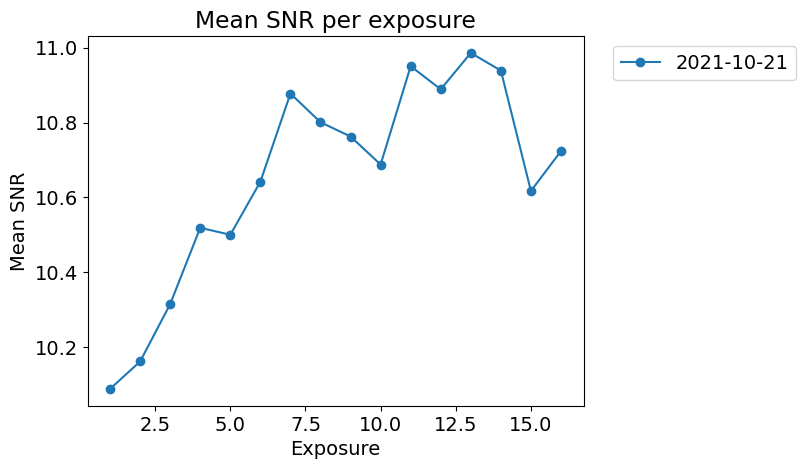

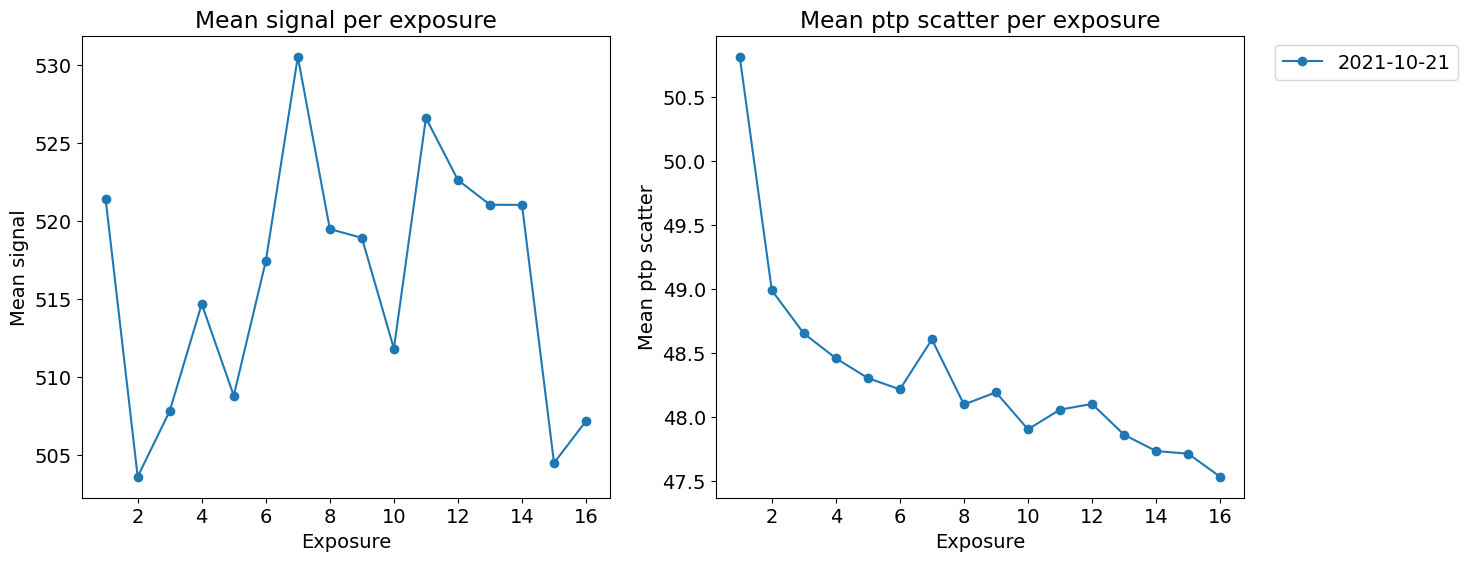

In [14]:
# Calculate and plot mean snr per exposure

# PLOT EACH NIGHT SEPARATELY
# for night in nightlist:
#     mean_snr_per_exp = np.mean(snr_all[night], axis=1)

#     # print(np.shape(mean_snr_per_exp))

#     plt.plot(np.arange(1, len(mean_snr_per_exp) + 1), mean_snr_per_exp, "-o", color="#08c2bc")
#     plt.xlabel("Exposure")
#     plt.ylabel("Mean SNR")
#     plt.title(f"Mean SNR per exposure for {night}")

#     plt.show()


# PUT ALL NIGHTS IN THE SAME PLOT
for night in nightlist:
    mean_snr_per_exp = np.mean(snr_all[night][0], axis=1)

    plt.plot(np.arange(1, len(mean_snr_per_exp) + 1), mean_snr_per_exp, "-o", label=night)


plt.xlabel("Exposure")
plt.ylabel("Mean SNR")
plt.title(f"Mean SNR per exposure")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()



fig, axs = plt.subplots(1, 2, figsize=(15,6), sharey=False)

# PLOT SIGNAL PER EXPOSURE
for night in nightlist:
    mean_sig_per_exp = np.mean(snr_all[night][1], axis=1)
    mean_noise_per_exp = np.mean(snr_all[night][2], axis=1)

    axs[0].plot(np.arange(1, len(mean_sig_per_exp) + 1), mean_sig_per_exp, "-o", label=night)
    axs[1].plot(np.arange(1, len(mean_noise_per_exp) + 1), mean_noise_per_exp, "-o", label=night)

axs[0].set_xlabel("Exposure")
axs[0].set_ylabel("Mean signal")
axs[0].set_title(f"Mean signal per exposure")

axs[1].set_xlabel("Exposure")
axs[1].set_ylabel("Mean ptp scatter")
axs[1].set_title(f"Mean ptp scatter per exposure")
axs[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

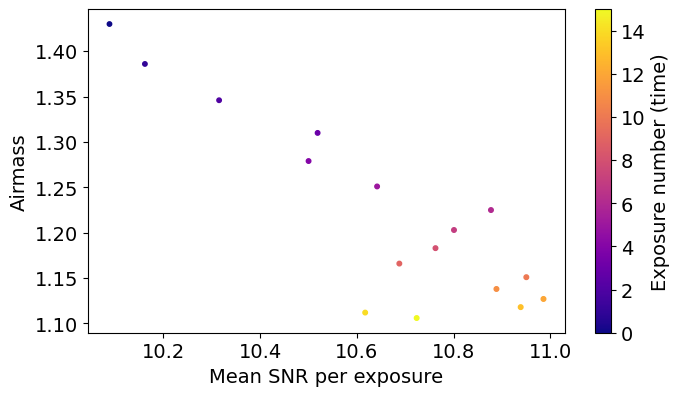

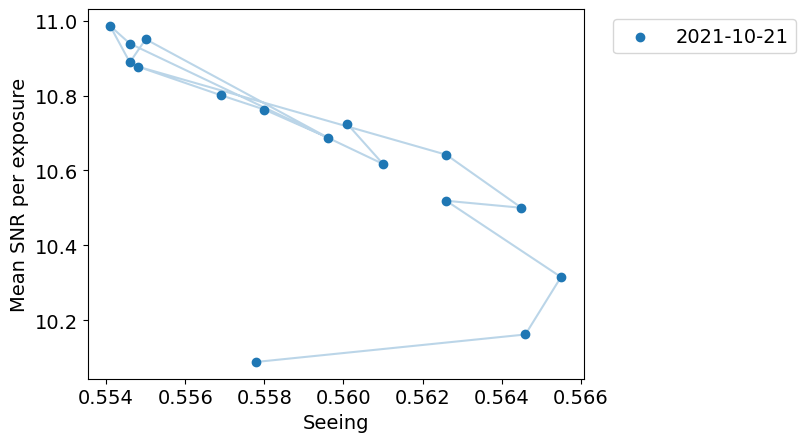

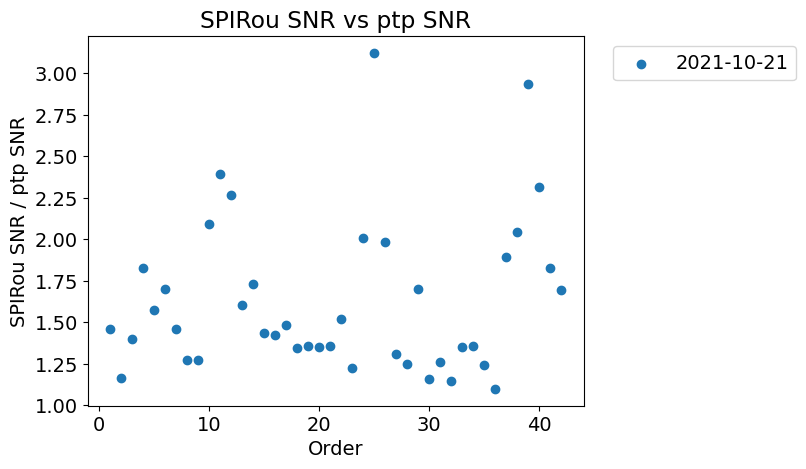

In [15]:
# Compare with airmass and seeing and SNR

# Get header values for each exposure
airmass = {}
seeing = {}
spirSNR = {}

for night in nightlist:
    airmass[night], seeing[night], spirSNR[night] = get_header_info(night, option="basic")


# Plot my SNR vs airmass, color-coded by exposure
plt.figure(figsize=(7.7,4.2))

for night in nightlist:
    # Get mean SNR per exposure
    mean_snr_per_exp = np.mean(snr_all[night][0], axis=1)
    
    # Plot
    plt.scatter(mean_snr_per_exp, airmass[night], mean_snr_per_exp, c=np.arange(len(mean_snr_per_exp)), cmap="plasma")
    # plt.plot(mean_snr_per_exp, airmass[night], "k", alpha=0.3)  # connect exposures from a same night with a line

plt.xlabel("Mean SNR per exposure")
plt.ylabel("Airmass")
plt.colorbar(label='Exposure number (time)')
# plt.ylim(1.07,1.4)
plt.show()


# Plot my SNR vs seeing

for night in nightlist:
    # Get mean SNR per exposure
    mean_snr_per_exp = np.mean(snr_all[night][0], axis=1)
    
    # Plot
    plt.scatter(seeing[night], mean_snr_per_exp, label=night)
    plt.plot(seeing[night], mean_snr_per_exp, alpha=0.3)  # connect exposures from a same night with a line

plt.xlabel("Seeing")
plt.ylabel("Mean SNR per exposure")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()


# Plot my SNR vs SPIRou SNR

for night in nightlist:
    # Get mean SNR per order
    mean_snr_per_ord = np.mean(snr_all[night][0], axis=0)
    spir_mean_snr_ord = np.mean(spirSNR[night], axis=0)
    snr_ratio = spir_mean_snr_ord / mean_snr_per_ord
    
    # Plot
    plt.scatter(np.arange(1, len(mean_snr_per_ord) + 1)[:42], snr_ratio[:42], label=night)

plt.xlabel("Order")
plt.ylabel("SPIRou SNR / ptp SNR")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.title("SPIRou SNR vs ptp SNR")#, " + night)
plt.show()

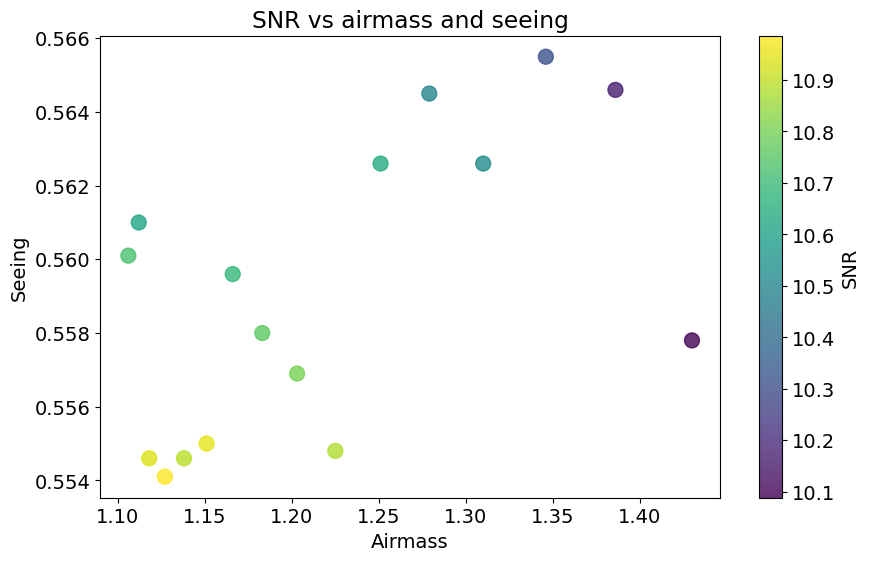

In [16]:
# Make a contour plot of SNR vs airmass and seeing

mean_SNR_exposure_all = np.array([])
airmass_SNR_all = np.array([])
seeing_SNR_all = np.array([])

for night in nightlist:
    # Get mean SNR per exposure
    mean_snr_per_exp = np.mean(snr_all[night][0], axis=1)
    
    mean_SNR_exposure_all = np.concatenate((mean_SNR_exposure_all, mean_snr_per_exp))
    
    # Add airmass and seeing values to their respective arrays
    airmass_SNR_all = np.concatenate((airmass_SNR_all, airmass[night]))
    seeing_SNR_all = np.concatenate((seeing_SNR_all, seeing[night]))


plt.figure(figsize=(10, 6))
plt.scatter(airmass_SNR_all, seeing_SNR_all, c=mean_SNR_exposure_all, s=115, cmap='viridis', alpha=0.8)

plt.colorbar(label="SNR")
plt.xlabel("Airmass")
plt.ylabel("Seeing")
plt.title("SNR vs airmass and seeing")
plt.show()

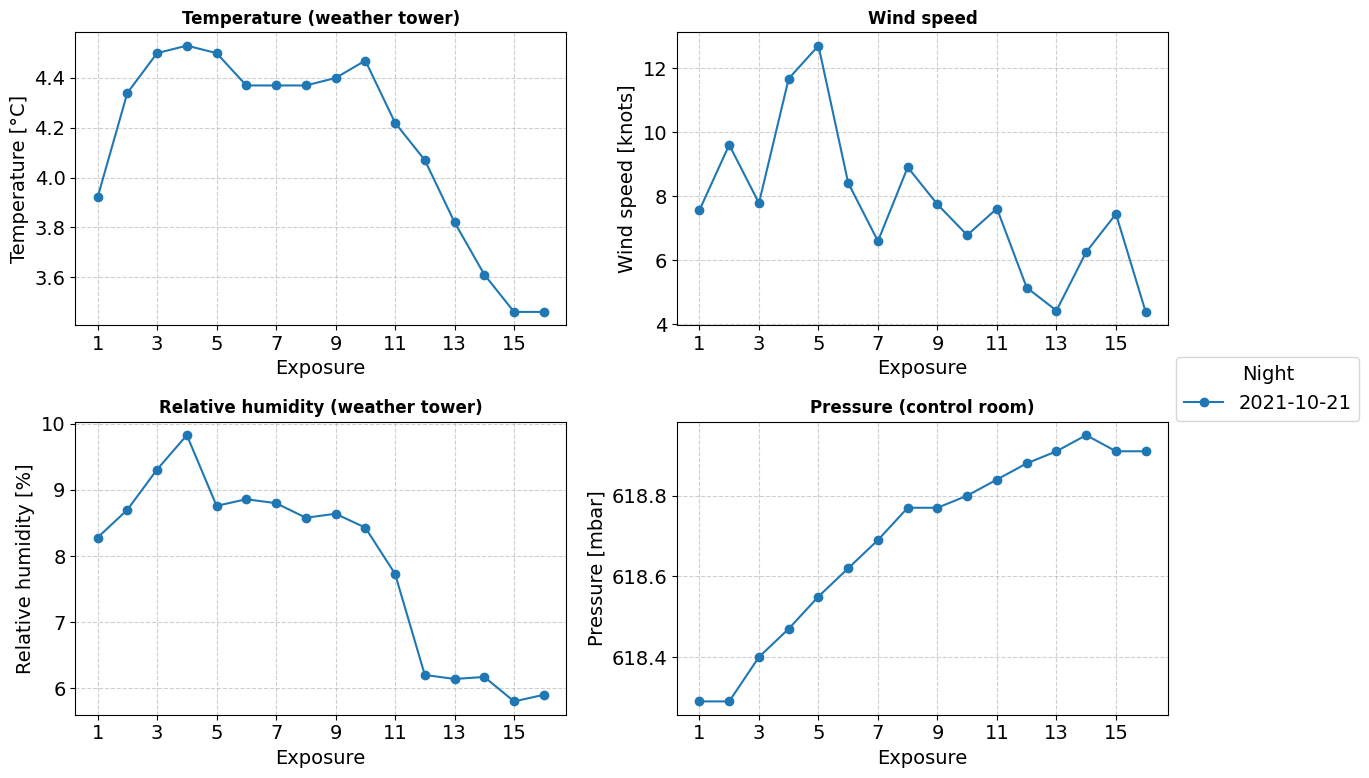

In [17]:
# See if other weather parameters influenced the SNR

params = ["Temperature", "Wind speed", "Relative humidity", "Pressure"]
params_titles = ["Temperature (weather tower)", "Wind speed", "Relative humidity (weather tower)", "Pressure (control room)"]
units = ["[°C]", "[knots]", "[%]", "[mbar]"]
colors = sns.color_palette("tab10", 10) + sns.color_palette("Set3", 1)  # unique colors for each night

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)  # 2 rows, 2 columns

for i, param in enumerate(params):
    ax = axes[i // 2, i % 2]  # locate subplot in a 2x2 grid

    for j, night in enumerate(nightlist):
        values = get_header_info(night, option="parameters")[i]  # Shift index since Moon Phase & Altitude are removed
        ax.plot(range(1, len(values) + 1), values, marker="o", linestyle="-", label=night, color=colors[j])

    ax.set_title(params_titles[i], fontsize=12, fontweight="bold")
    ax.set_xlabel("Exposure")
    ax.set_xticks(np.arange(1, len(values) + 1, 2))
    ax.set_ylabel(param + " " + units[i])
    ax.grid(True, linestyle="--", alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Night", loc="center right", bbox_to_anchor=(1.15, 0.5))
plt.tight_layout()
plt.show()

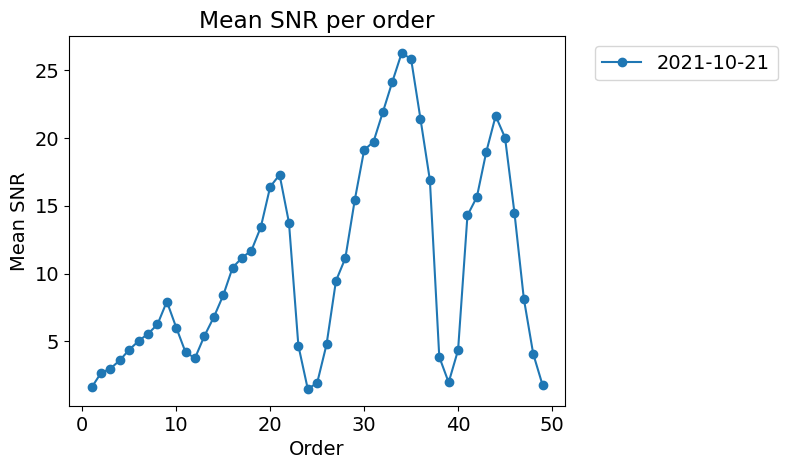

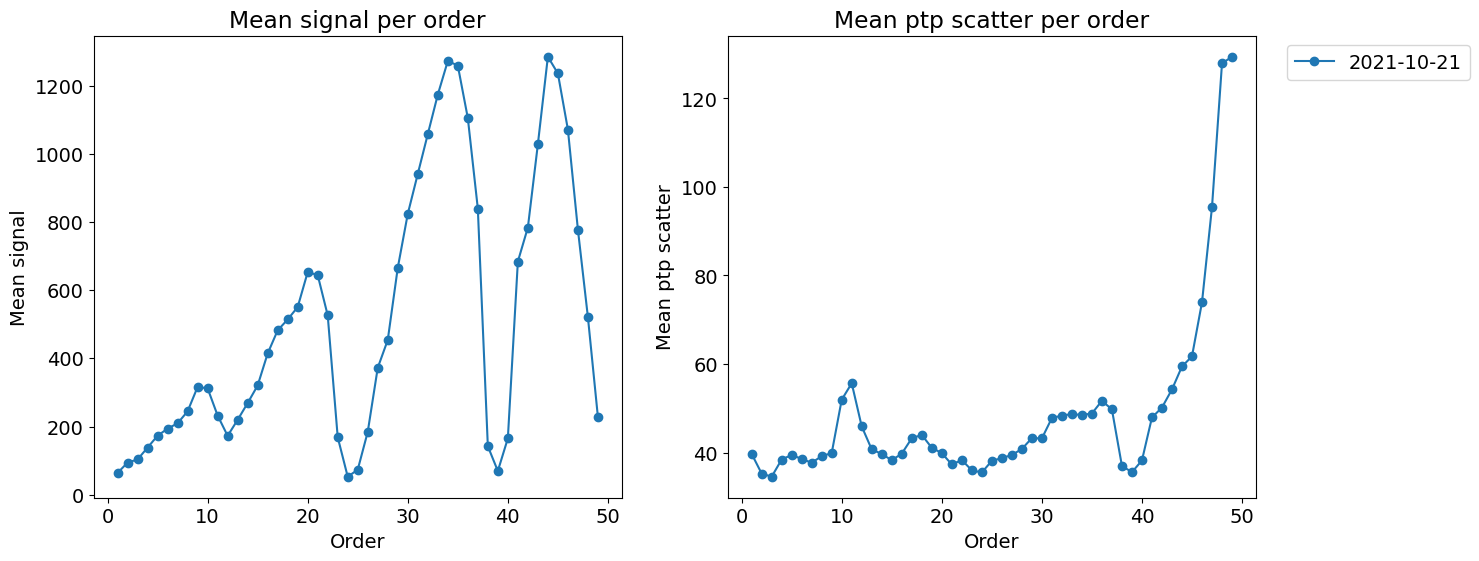

In [18]:
# Calculate and plot mean snr per order

# # PLOT EACH NIGHT SEPARATELY
# for night in nightlist:
#     mean_snr_per_ord = np.mean(snr_all[night], axis=0)

#     # print(np.shape(mean_snr_per_ord))

#     plt.plot(np.arange(1, len(mean_snr_per_ord) + 1), mean_snr_per_ord, "-o", color="#06bf12")
#     plt.xlabel("Order")
#     plt.ylabel("Mean SNR")
#     plt.title(f"Mean SNR per order for {night}")

#     plt.show()


# PUT ALL NIGHTS IN THE SAME PLOT
for night in nightlist:
    mean_snr_per_ord = np.mean(snr_all[night][0], axis=0)

    # print(np.shape(mean_snr_per_ord))

    plt.plot(np.arange(1, len(mean_snr_per_ord) + 1), mean_snr_per_ord, "-o", label=night)

    
plt.xlabel("Order")
plt.ylabel("Mean SNR")
plt.title(f"Mean SNR per order")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()



fig, axs = plt.subplots(1, 2, figsize=(15,6), sharey=False)

# PLOT SIGNAL PER EXPOSURE
for night in nightlist:
    mean_sig_per_exp = np.mean(snr_all[night][1], axis=0)
    mean_noise_per_exp = np.mean(snr_all[night][2], axis=0)

    axs[0].plot(np.arange(1, len(mean_sig_per_exp) + 1), mean_sig_per_exp, "-o", label=night)
    axs[1].plot(np.arange(1, len(mean_noise_per_exp) + 1), mean_noise_per_exp, "-o", label=night)

axs[0].set_xlabel("Order")
axs[0].set_ylabel("Mean signal")
axs[0].set_title(f"Mean signal per order")

axs[1].set_xlabel("Order")
axs[1].set_ylabel("Mean ptp scatter")
axs[1].set_title(f"Mean ptp scatter per order")
axs[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

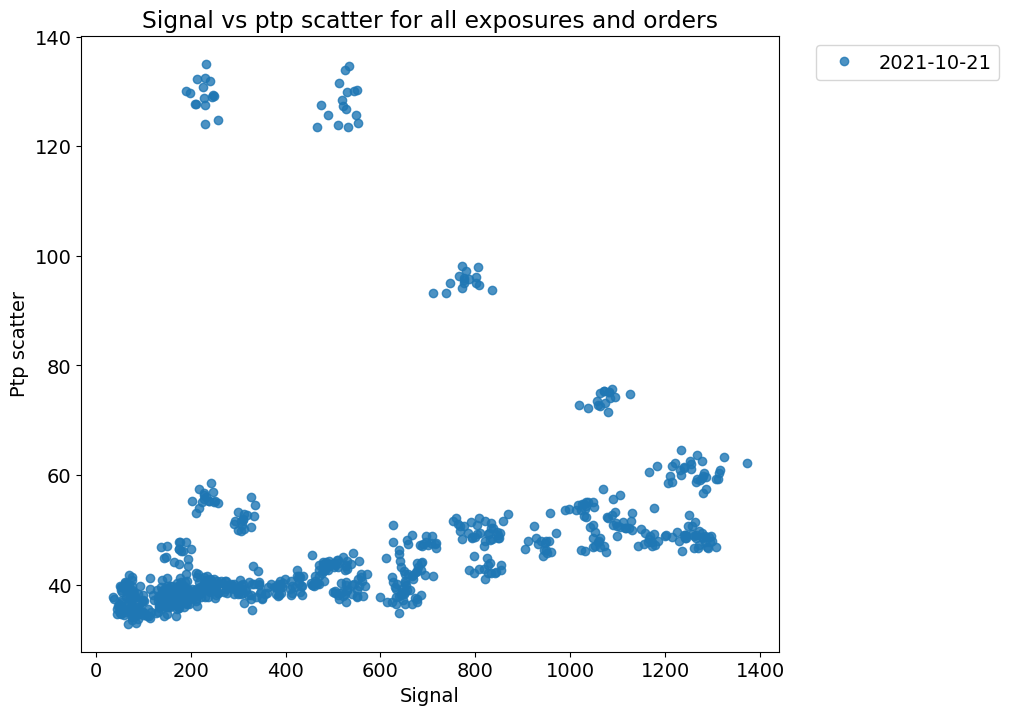

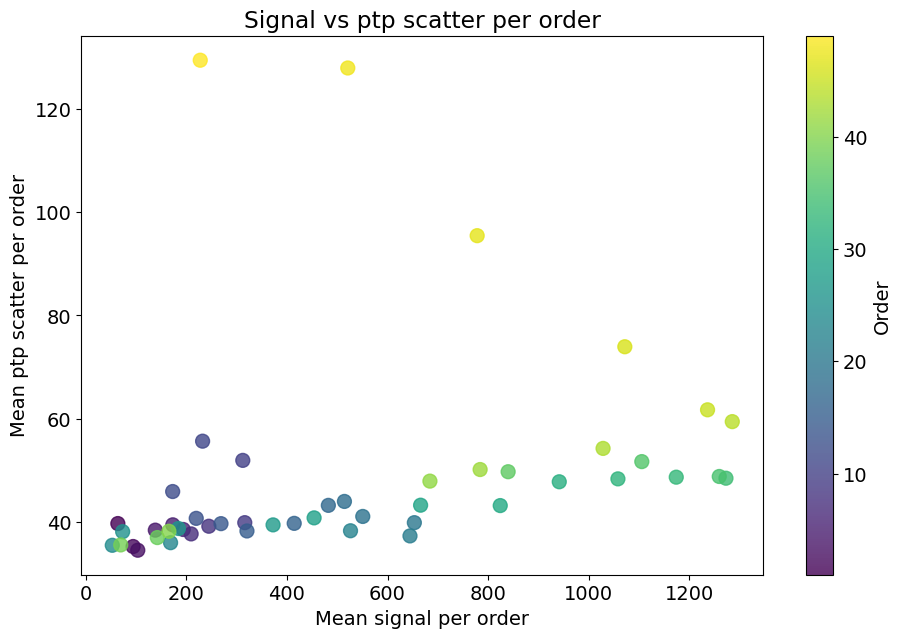

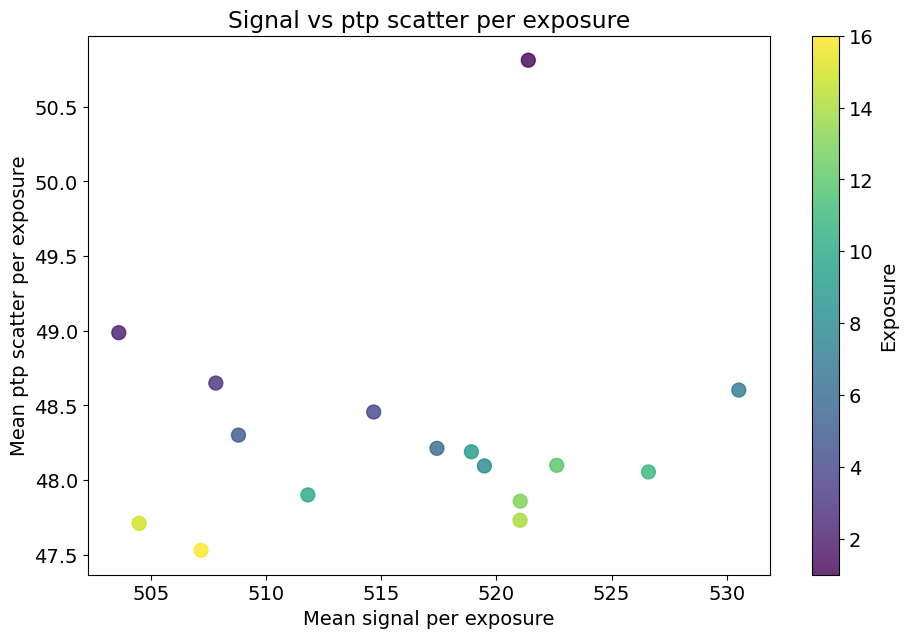

In [19]:
# PTP SCATTER AS A FCT OF SIGNAL

plt.figure(figsize=(9,8))

for night in nightlist:

    plt.plot(snr_all[night][1].flatten(), snr_all[night][2].flatten(), "o", alpha=0.8, label=night)

    
plt.xlabel("Signal")
plt.ylabel("Ptp scatter")
plt.title(f"Signal vs ptp scatter for all exposures and orders")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()


# MEAN PTP SCATTER AND SIGNAL, PER ORDER
plt.figure(figsize=(11,7))

for night in nightlist:
    mean_sig_per_ord = np.mean(snr_all[night][1], axis=0)
    mean_ptp_per_ord = np.mean(snr_all[night][2], axis=0)
    
    plt.scatter(mean_sig_per_ord, mean_ptp_per_ord, c=np.arange(1, 50), s=100, cmap='viridis', alpha=0.8)

    
plt.xlabel("Mean signal per order")
plt.ylabel("Mean ptp scatter per order")
plt.title(f"Signal vs ptp scatter per order")
plt.colorbar(label="Order")
plt.show()


# MEAN PTP SCATTER AND SIGNAL, PER EXPOSURE
plt.figure(figsize=(11,7))

for night in nightlist:
    mean_sig_per_exp = np.mean(snr_all[night][1], axis=1)
    mean_ptp_per_exp = np.mean(snr_all[night][2], axis=1)
    
    plt.scatter(mean_sig_per_exp, mean_ptp_per_exp, c=np.arange(1, len(mean_sig_per_exp) + 1), s=100, cmap='viridis', alpha=0.8)

    
plt.xlabel("Mean signal per exposure")
plt.ylabel("Mean ptp scatter per exposure")
plt.title(f"Signal vs ptp scatter per exposure")
plt.colorbar(label="Exposure")
plt.show()

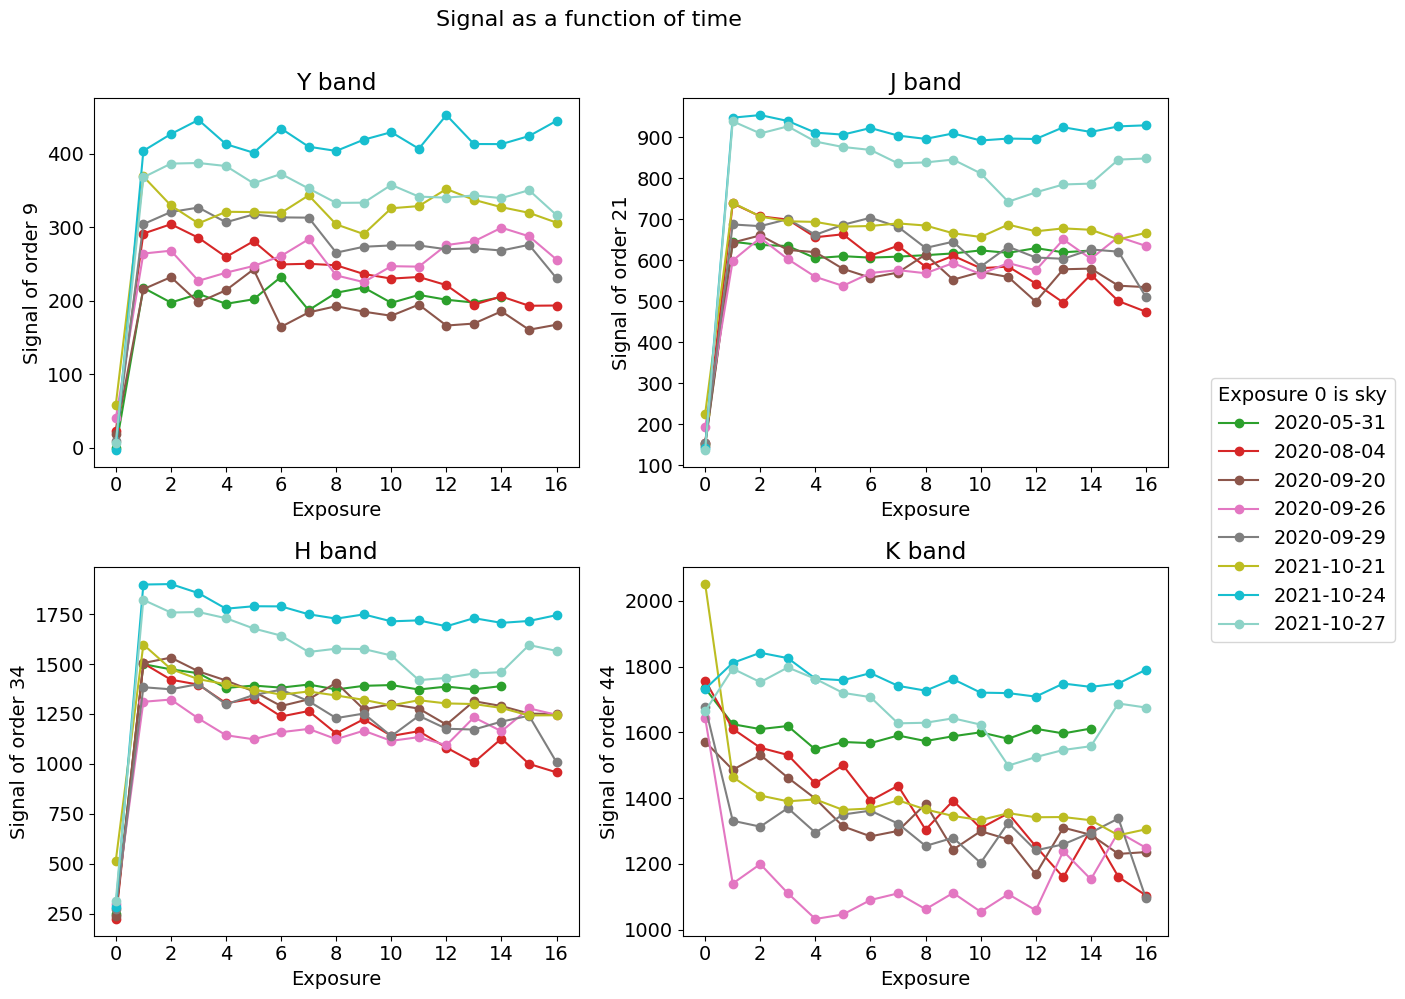

In [7]:
# Define the bands and colors
bands = ["Y", "J", "H", "K"]
colors = sns.color_palette("tab10", 10) + sns.color_palette("Set3", 1)  # unique colors for each night

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the 2x2 axes array for easier iteration
axs = axs.flatten()

# Create a list to store handles and labels for the legend
handles, labels = [], []

# Loop over orders (Y, J, H, K) with their respective indices
for i, order in enumerate([8, 20, 33, 43]):
    for night in nightlist:
        # Extract the signal per exposure and sky signal for the given order
        sig_per_exp = snr_all[night][1][:, order]
        sig_sky = snr_all[night][3][1][order]
        sig_full = np.insert(sig_per_exp, 0, sig_sky)

        if sig_sky != 0:  # If the night has a sky observation
            # Plot the data in the corresponding subplot
            line, = axs[i].plot(np.arange(0, len(sig_per_exp) + 1), sig_full, "-o", color=colors[nightlist.index(night)], label=night)

            # Append the handle and label for the legend
            if i == 0:  # Only add the label once for the first subplot
                handles.append(line)
                labels.append(night)

    axs[i].set_xlabel("Exposure")
    axs[i].set_ylabel(f"Signal of order {order + 1}")
    axs[i].set_title(f"{bands[i]} band")
    axs[i].set_xticks(np.arange(0, len(sig_per_exp) + 1, 2))

plt.tight_layout()
fig.suptitle("Signal as a function of time", fontsize=16, y=1)
fig.legend(handles, labels, title="Exposure 0 is sky", bbox_to_anchor=(1.01, 0.5), loc="center left")
plt.tight_layout()
plt.show()

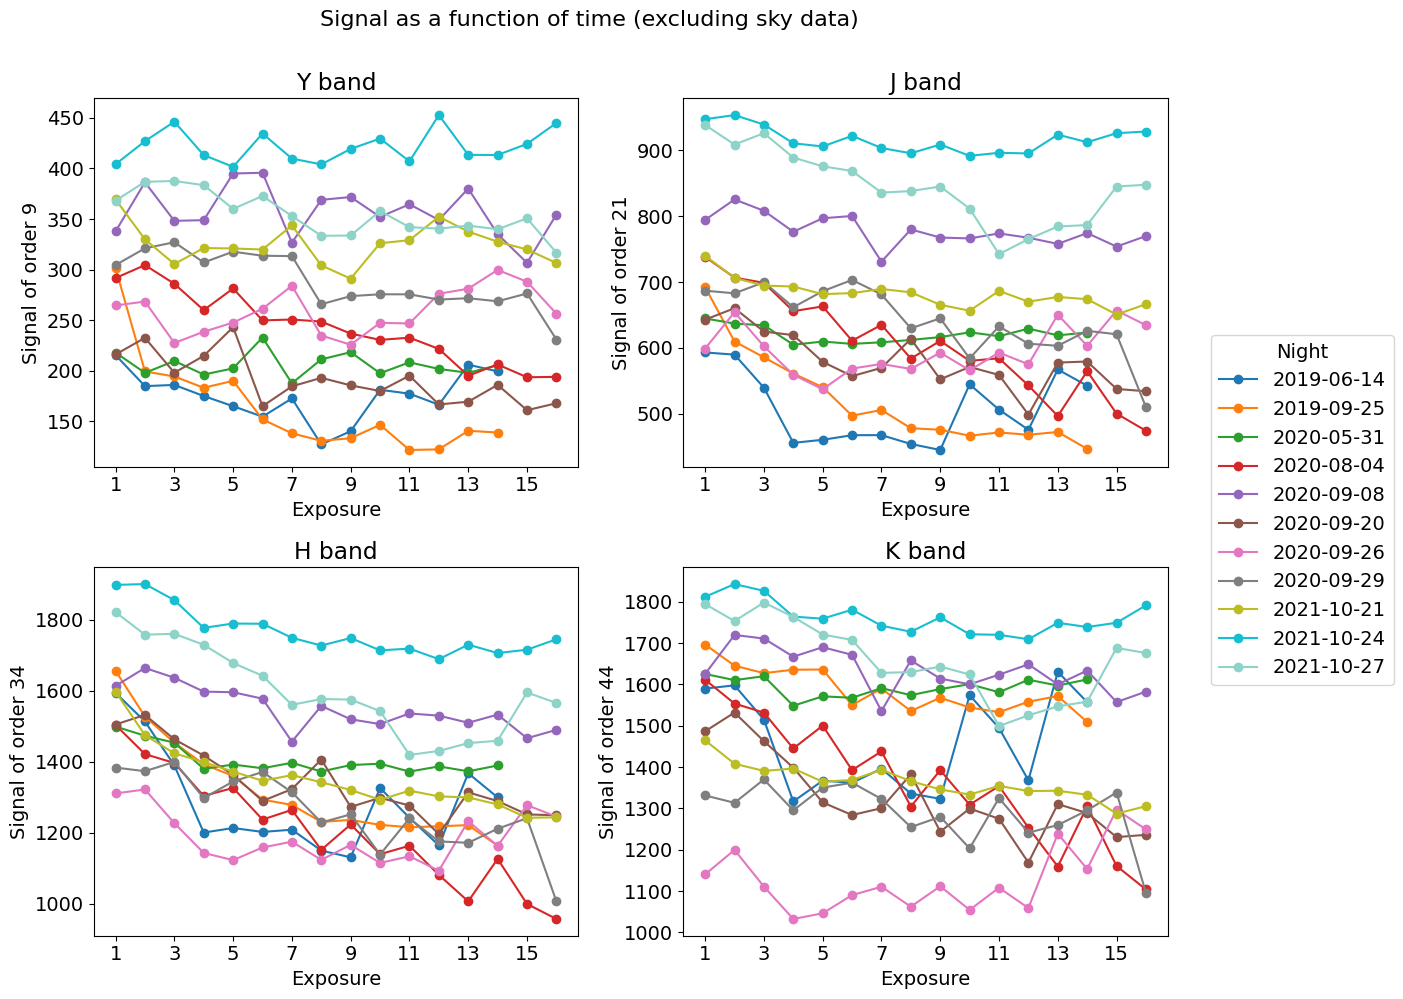

In [10]:
# Define the bands and colors
bands = ["Y", "J", "H", "K"]
colors = sns.color_palette("tab10", 10) + sns.color_palette("Set3", 1)  # unique colors for each night

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the 2x2 axes array for easier iteration
axs = axs.flatten()

# Create a list to store handles and labels for the legend
handles, labels = [], []

# Loop over orders (Y, J, H, K) and their respective indices
for i, order in enumerate([8, 20, 33, 43]):
    for j, night in enumerate(nightlist):
        # Signal per exposure for the given order
        sig_per_exp = snr_all[night][1][:, order]
        
        # Plot the signal for the night without the sky data
        line, = axs[i].plot(np.arange(1, len(sig_per_exp) + 1), sig_per_exp, "-o", color=colors[j], label=night)

        # Append the handle and label for the legend
        if i == 0:  # only add the label once for the first subplot
            handles.append(line)
            labels.append(night)
        
        # Save data to file
        with open('snr_data_bands_with_persi.txt', "a") as f:
            f.write(f"{bands[i]}\t{night}\n")
            for k in range(len(sig_per_exp)):
                f.write(f"{k + 1}\t{sig_per_exp[k]}\n")
            f.write("\n")

    # Set the labels and titles for each subplot
    axs[i].set_xlabel("Exposure")
    axs[i].set_ylabel(f"Signal of order {order + 1}")
    axs[i].set_title(f"{bands[i]} band")
    axs[i].set_xticks(np.arange(1, len(sig_per_exp) + 1, 2))

fig.suptitle("Signal as a function of time (excluding sky data)", fontsize=16, y=1)
fig.legend(handles, labels, title="Night", bbox_to_anchor=(1.01, 0.5), loc="center left")
plt.tight_layout()
plt.show()

In [19]:
# COMPARE BEFORE AND AFTER PERSICORR
# Read the files

# Define your bands and map them to indices
band_to_idx = {band: i for i, band in enumerate(bands)}  # dict

# Define your night list in the same order used when plotting
night_to_idx = {night: i for i, night in enumerate(nightlist)}  # dict

# Preallocate array with NaNs to account for variable-length exposures
data_bands = np.full((2, 4, 11, 16), np.nan)  # [0] is with persi, [1] is without persi 
files = ["snr_data_bands_with_persi.txt", "snr_data_bands.txt"]

# Read and parse the file
for i in range(len(files)):
    with open(files[i], "r") as f:
        current_band = None
        current_night = None
        exposure_idx = 0

        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines

            # Header line with band and night
            if line[0] in bands and '\t' in line:
                parts = line.split('\t')
                current_band = parts[0]
                current_night = parts[1]
                exposure_idx = 0  # reset exposure counter
                continue

            # Data line: exposure index and signal
            if current_band and current_night:
                parts = line.split('\t')
                signal = float(parts[1])
                b_idx = band_to_idx[current_band]
                n_idx = night_to_idx[current_night]
                data_bands[i][b_idx, n_idx, exposure_idx] = signal
                exposure_idx += 1


# Make the plot
data_diff = data_bands[0] - data_bands[1]  # shape: (4, 11, 16)

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

# Legend handles and labels
handles, labels = [], []

# Loop over bands
for i, band in enumerate(bands):
    for j, night in enumerate(nightlist):
        # Retrieve difference signal, excluding sky exposure at index 0
        diff_signal = data_diff[i, j, 1:]

        if not np.all(np.isnan(diff_signal)):
            line, = axs[i].plot(
                np.arange(1, len(diff_signal) + 1),
                diff_signal,
                "-o",
                color=colors[j],
                label=night
            )

            if i == 0:
                handles.append(line)
                labels.append(night)

    axs[i].set_xlabel("Exposure")
    axs[i].set_ylabel("Signal difference")
    axs[i].set_title(f"{band} band")
    axs[i].set_xticks(np.arange(1, len(diff_signal) + 1, 2))

fig.suptitle("Difference in signal as a function of time (before persicorr - after persicorr)", fontsize=16, y=1)
fig.legend(handles, labels, title="Night", bbox_to_anchor=(1.01, 0.5), loc="center left")
plt.tight_layout()
plt.show()

In [ ]:
# COMPARE BEFORE AND AFTER PERSICORR
# Make the plot

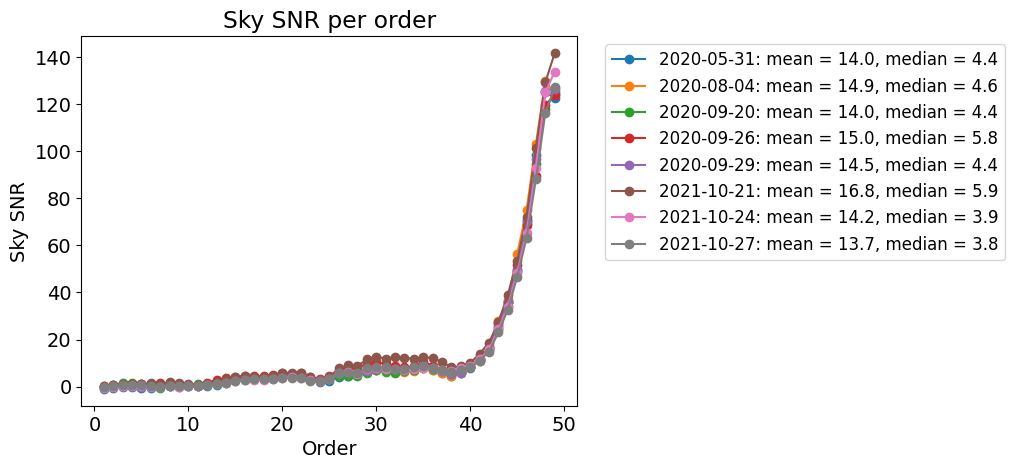

In [15]:
# SKY SNR

for night in nightlist:
    sky_snr_ord = snr_all[night][3][0]
    mean_sky_SNR = np.mean(sky_snr_ord)
    median_sky_SNR = np.median(sky_snr_ord)
    
    if median_sky_SNR != 0.0:  # exlude night without a sky observation
        plt.plot(np.arange(1, len(sky_snr_ord) + 1), sky_snr_ord, "-o", label=f"{night}: mean = {mean_sky_SNR:.1f}, median = {median_sky_SNR:.1f}")

    
plt.xlabel("Order")
plt.ylabel("Sky SNR")
plt.title(f"Sky SNR per order")
plt.legend(fontsize=12, ncol=1, bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

### Make the same plots but with median

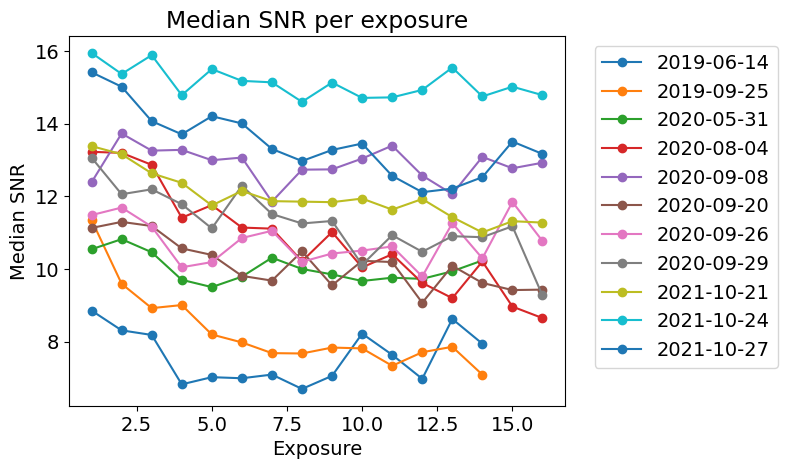

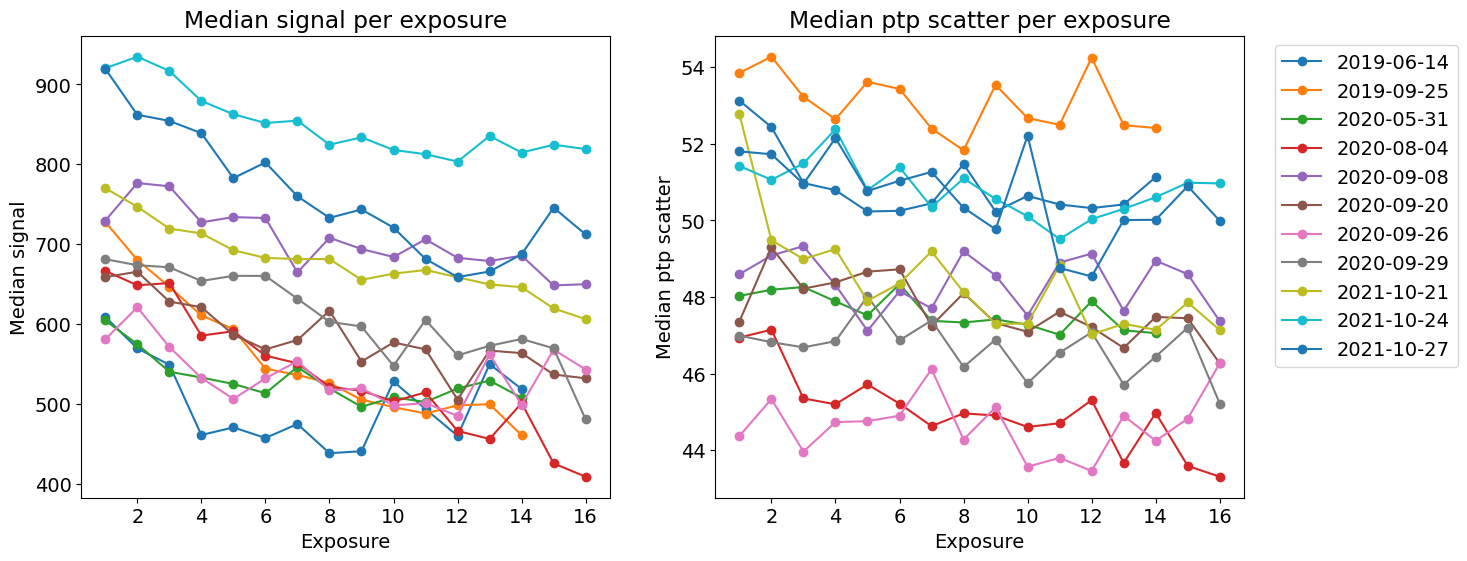

In [16]:
# Calculate and plot median SNR per exposure 
for night in nightlist:
    median_snr_per_exp = np.median(snr_all[night][0], axis=1)  

    plt.plot(np.arange(1, len(median_snr_per_exp) + 1), median_snr_per_exp, "-o", label=night)

plt.xlabel("Exposure")
plt.ylabel("Median SNR")
plt.title(f"Median SNR per exposure")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15,6), sharey=False)

# PLOT SIGNAL AND NOISE PER EXPOSURE
for night in nightlist:
    median_sig_per_exp = np.median(snr_all[night][1], axis=1)
    median_noise_per_exp = np.median(snr_all[night][2], axis=1)

    axs[0].plot(np.arange(1, len(median_sig_per_exp) + 1), median_sig_per_exp, "-o", label=night)
    axs[1].plot(np.arange(1, len(median_noise_per_exp) + 1), median_noise_per_exp, "-o", label=night)

axs[0].set_xlabel("Exposure")
axs[0].set_ylabel("Median signal")
axs[0].set_title(f"Median signal per exposure")

axs[1].set_xlabel("Exposure")
axs[1].set_ylabel("Median ptp scatter")
axs[1].set_title(f"Median ptp scatter per exposure")
axs[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

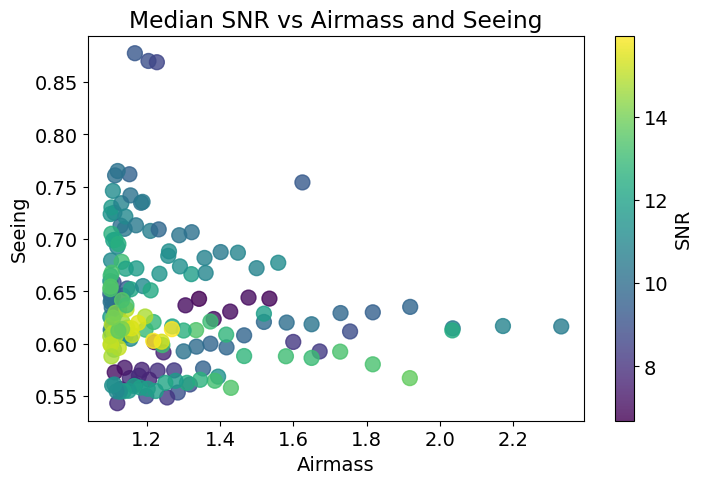

In [17]:
# Make a contour plot of SNR vs airmass and seeing

median_SNR_exposure_all = np.array([])
airmass_SNR_all = np.array([])  
seeing_SNR_all = np.array([])

for night in nightlist:
    # Get median SNR per exposure
    median_snr_per_exp = np.median(snr_all[night][0], axis=1)
    median_SNR_exposure_all = np.concatenate((median_SNR_exposure_all, median_snr_per_exp))
    
    # Add airmass and seeing values to their respective arrays
    airmass_SNR_all = np.concatenate((airmass_SNR_all, airmass[night]))
    seeing_SNR_all = np.concatenate((seeing_SNR_all, seeing[night]))

plt.figure(figsize=(8, 5))
plt.scatter(airmass_SNR_all, seeing_SNR_all, c=median_SNR_exposure_all, s=115, cmap='viridis', alpha=0.8)

plt.colorbar(label="SNR")
plt.xlabel("Airmass")
plt.ylabel("Seeing")
plt.title("Median SNR vs Airmass and Seeing")
plt.show()

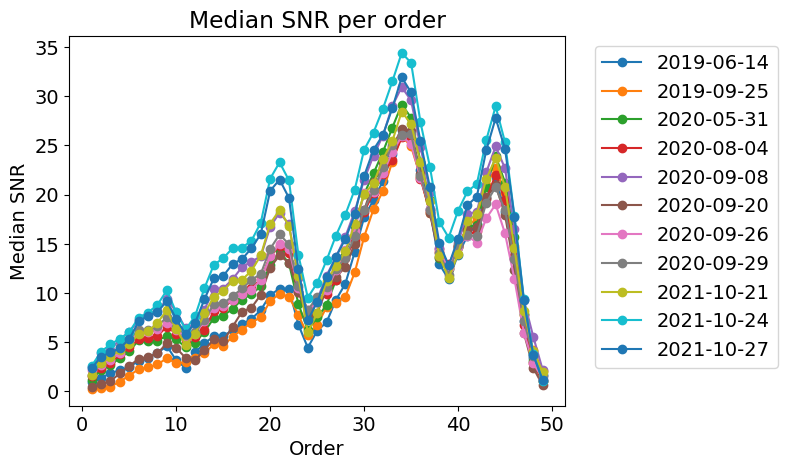

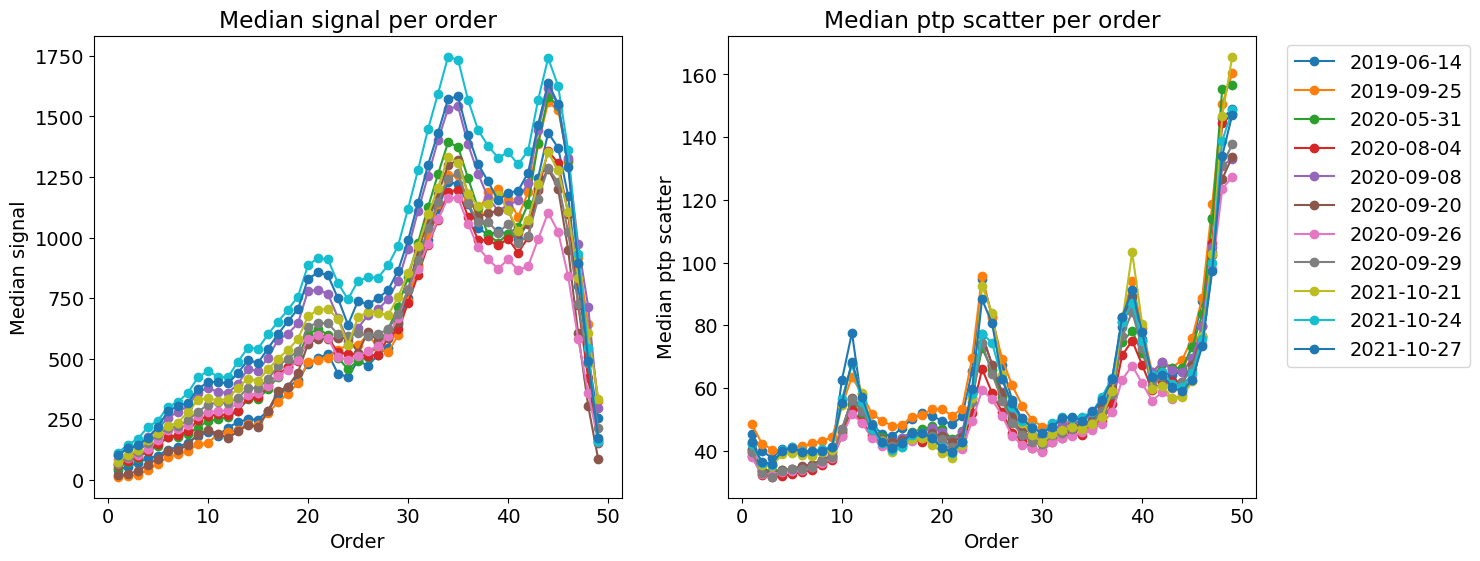

In [18]:
# Calculate and plot median snr per order

for night in nightlist:
    median_snr_per_ord = np.median(snr_all[night][0], axis=0)

    plt.plot(np.arange(1, len(median_snr_per_ord) + 1), median_snr_per_ord, "-o", label=night)

    
plt.xlabel("Order")
plt.ylabel("Median SNR")
plt.title(f"Median SNR per order")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()


fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# PLOT SIGNAL PER ORDER
for night in nightlist:
    median_sig_per_ord = np.median(snr_all[night][1], axis=0)
    median_noise_per_ord = np.median(snr_all[night][2], axis=0)

    axs[0].plot(np.arange(1, len(median_sig_per_ord) + 1), median_sig_per_ord, "-o", label=night)
    axs[1].plot(np.arange(1, len(median_noise_per_ord) + 1), median_noise_per_ord, "-o", label=night)

axs[0].set_xlabel("Order")
axs[0].set_ylabel("Median signal")
axs[0].set_title(f"Median signal per order")

axs[1].set_xlabel("Order")
axs[1].set_ylabel("Median ptp scatter")
axs[1].set_title(f"Median ptp scatter per order")
axs[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

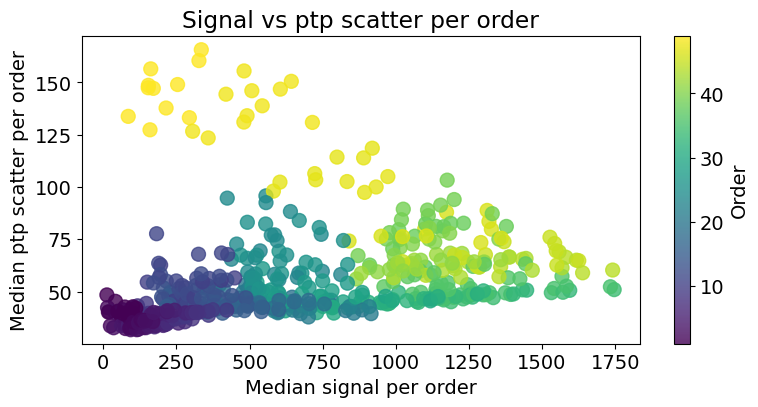

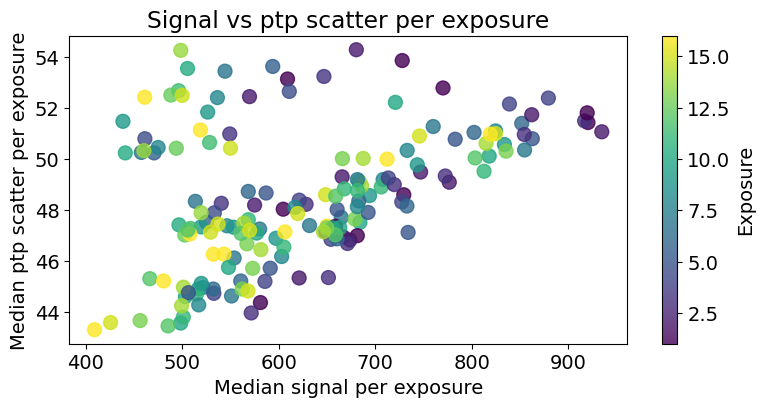

In [19]:
# MEDIAN PTP SCATTER AND SIGNAL, PER ORDER
plt.figure(figsize=(9,4))

for night in nightlist:
    median_sig_per_ord = np.median(snr_all[night][1], axis=0)  # Changed to median
    median_ptp_per_ord = np.median(snr_all[night][2], axis=0)  # Changed to median
    
    plt.scatter(median_sig_per_ord, median_ptp_per_ord, c=np.arange(1, 50), s=100, cmap='viridis', alpha=0.8)

plt.xlabel("Median signal per order")
plt.ylabel("Median ptp scatter per order")
plt.title(f"Signal vs ptp scatter per order")
plt.colorbar(label="Order")
plt.show()


# MEDIAN PTP SCATTER AND SIGNAL, PER EXPOSURE
plt.figure(figsize=(9,4))

for night in nightlist:
    median_sig_per_exp = np.median(snr_all[night][1], axis=1)  # Changed to median
    median_ptp_per_exp = np.median(snr_all[night][2], axis=1)  # Changed to median
    
    plt.scatter(median_sig_per_exp, median_ptp_per_exp, c=np.arange(1, len(median_sig_per_exp) + 1), s=100, cmap='viridis', alpha=0.8)

plt.xlabel("Median signal per exposure")
plt.ylabel("Median ptp scatter per exposure")
plt.title(f"Signal vs ptp scatter per exposure")
plt.colorbar(label="Exposure")
plt.show()